Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
import statsmodels.api as sm



In [11]:

model_data = pd.read_csv('main_data/cbt/C01.csv')
model_data['timestamp'] = pd.to_datetime(model_data['timestamp'] , unit='s')


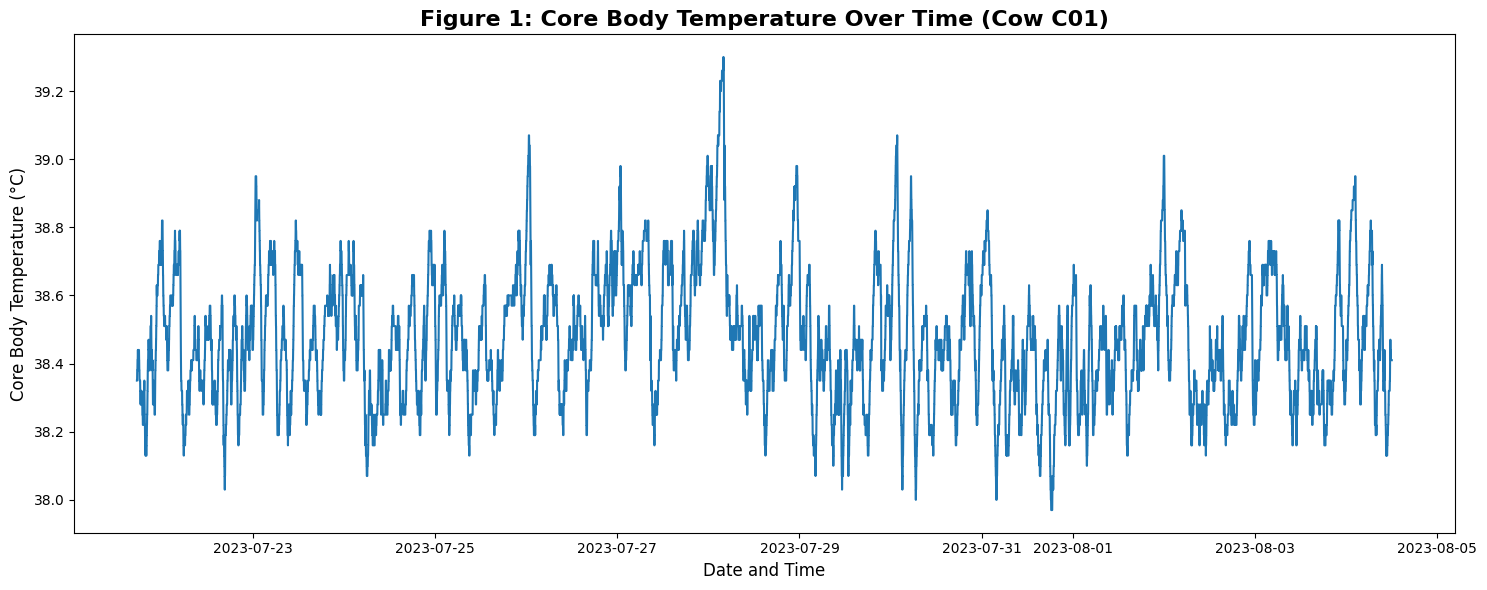

In [12]:


plt.figure(figsize=(15, 6)) 
plt.plot(model_data['timestamp'], model_data['temperature_C'])
plt.title('Figure 1: Core Body Temperature Over Time (Cow C01)', fontsize=16, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Core Body Temperature (°C)', fontsize=12)
plt.tight_layout()
plt.show()

In this post , we will be exploring Attractor Dynamics in the MMcows Dataset , which is a large scale multimodal biometric dataset measuring dairy cows.Specifically we will be using the Core body temperature(CBT) subset and within that subeset the data of Cow One. The goal of this analysis is to indentify attractors and/or repelors in the cows system that act as a self regulating system maintaining homeostasis. Consequently, we will examine how the rate of change in CBT correlates with its own lagged values . Afterwards, we will use Generalized Local Linear Approximation (GLLA) to remove noise and calculate the systems derivatives.However, first we will explore the dataset and explain the preprocessing steps we took.

C:\Users\Admin\AppData\Local\Temp\ipykernel_16316\4155613919.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  model_data['temp_change_smooth'] = model_data['temp_change'].rolling(window='30T').mean()


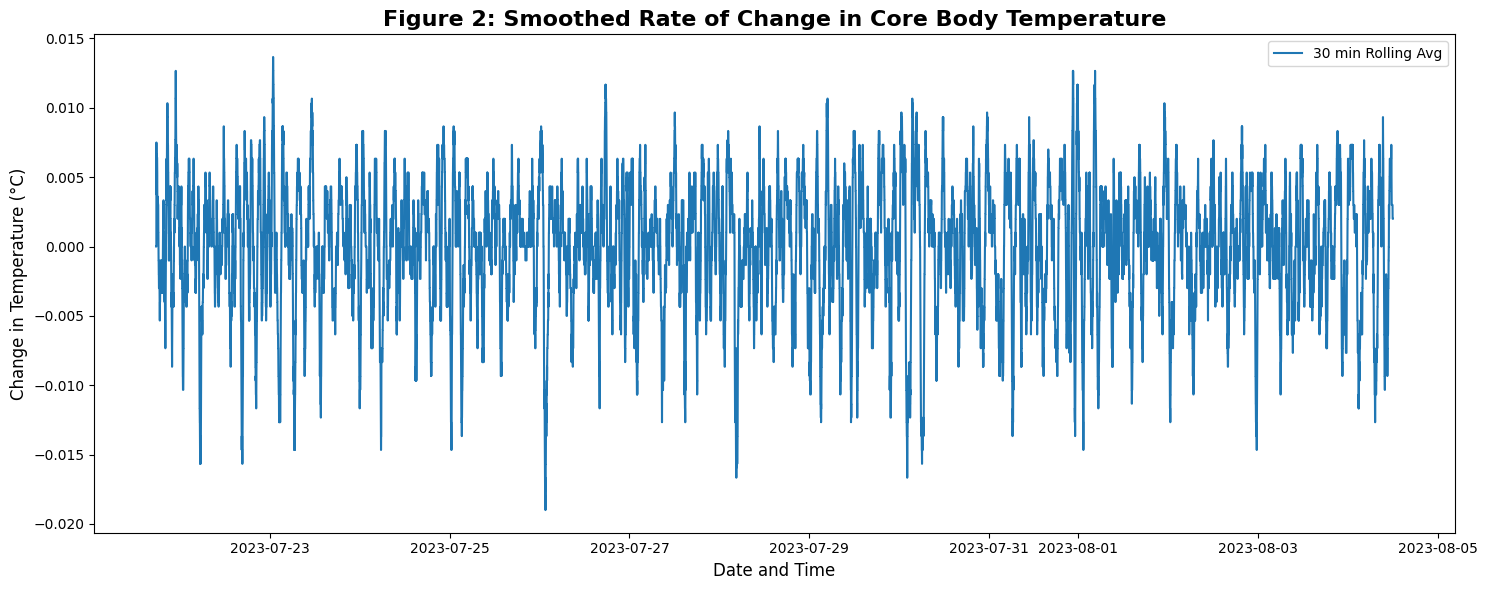

In [13]:

model_data['temp_change'] = model_data['temperature_C'].diff()
model_data = model_data.set_index('timestamp')
model_data['temp_change_smooth'] = model_data['temp_change'].rolling(window='30T').mean()
plt.figure(figsize=(15, 6))
plt.plot(model_data.index, model_data['temp_change_smooth'], label='30 min Rolling Avg')
plt.title('Figure 2: Smoothed Rate of Change in Core Body Temperature', fontsize=16, fontweight='bold')
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Change in Temperature (°C)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

model_data = model_data.reset_index()

This dataset was preprocessed by removing all missing rows or rows with "NA" values and converted the timestamps into standard datetime . After that we explored the raw data and mapped the CBT over the whole timespan(figure1).The CBT got recorded over 14 days and measured in one minute intervals.Figure 1 illustrates that the average body temperature hovers around 38.25 to 38.75 degress and that the internal body temperature does not flucuate that much with local maxima reaching 39.4 degrees and minima reaching 37.75 degrees.While this shows the general trend of the specific cow it does not provide any hidden mechanism. That is why we utilzed the change as outcome variable which is (CBT t+1 - CBTt)and mapped that variable as well. Because of the amount of data we have for one cow (around 19000)a rolling average of 30min or 30 datapoints was used to smooth out the data and do not have that much jitter in the plot(figure2).
Firstly we created a baseline model (figure3)using a Ordinary Least Squares (OLS) regression on the change variable and the temperature without any transformations. This was done to compare it to our future model.As expected the model had a low statistical power(R² = 0.002) but it was statistically significant for the linear term but not the quadratic term.

In [14]:

baseline_data = model_data.dropna(subset=['temperature_C', 'temp_change']).copy()
baseline_data['temp_centered'] = baseline_data['temperature_C'] - baseline_data['temperature_C'].mean()
y_raw = baseline_data['temp_change']
x1_raw = baseline_data['temp_centered']
X_raw = np.column_stack((x1_raw, x1_raw**2))
X_raw = sm.add_constant(X_raw)
res_raw = sm.OLS(y_raw, X_raw).fit(cov_type='HAC', cov_kwds={'maxlags': 1})
print('Figure 3:')
print(res_raw.summary())

Figure 3:
                            OLS Regression Results                            
Dep. Variable:            temp_change   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     16.87
Date:                Mon, 18 May 2026   Prob (F-statistic):           4.77e-08
Time:                        12:59:56   Log-Likelihood:                 54867.
No. Observations:               19830   AIC:                        -1.097e+05
Df Residuals:                   19827   BIC:                        -1.097e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      1.04

After looking at the baseline model it became apparent that we needed to filter out the noise.That is why we processed the data using a Savitzky-Golay (Savgol) filter and calculated the system's derivatives (GLLA). A window size of 21 was chosen, since the algorithm requires an odd number . This specific window size was choosen randomly. Before the analysis, the temperature data points were centered to prevent multicollinearity . Afterwards, we ran an OLS regression on the variables extracted from the Savgol filter . The model yielded an R² of 0.000(Figure 4), which is lower than our baseline model and suggests that Savgol filter did not help the regression find a better fit. However since this GLLA calculated only the first order derivative another regression with a second order deriviative will be calculated to confirm that no attractor is in the data.

In [15]:
from scipy.signal import savgol_filter
import statsmodels.api as sm
import numpy as np

window_size = 21 
poly_order = 2    
model_data['velocity_GLLA'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=1)
model_data['temp_GLLA'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=0)
model_data['temp_centered_GLLA'] = model_data['temp_GLLA'] - model_data['temp_GLLA'].mean()
glla_data = model_data.dropna(subset=['velocity_GLLA', 'temp_centered_GLLA']).copy()
y_glla = glla_data['velocity_GLLA']
x_glla = glla_data['temp_centered_GLLA']
X_glla = np.column_stack((x_glla, x_glla**2))
X_glla = sm.add_constant(X_glla)
res_glla = sm.OLS(y_glla, X_glla).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print('Figure 4:')
print(res_glla.summary())

Figure 4:
                            OLS Regression Results                            
Dep. Variable:          velocity_GLLA   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.02389
Date:                Mon, 18 May 2026   Prob (F-statistic):              0.976
Time:                        12:59:56   Log-Likelihood:                 74702.
No. Observations:               19831   AIC:                        -1.494e+05
Df Residuals:                   19828   BIC:                        -1.494e+05
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        2.68e-05      0.000      0.14

In [16]:
window_size = 21
poly_order = 3
model_data['accel_GLLA2'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=2)
model_data['velocity_GLLA2'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=1)
model_data['temp_GLLA2'] = savgol_filter(model_data['temperature_C'], window_length=window_size, polyorder=poly_order, deriv=0)
model_data['temp_centered_GLLA2'] = model_data['temp_GLLA2'] - model_data['temp_GLLA2'].mean()
glla_data = model_data.dropna(subset=['accel_GLLA2', 'velocity_GLLA2', 'temp_centered_GLLA2']).copy()
y_glla = glla_data['accel_GLLA2']
x_pos = glla_data['temp_centered_GLLA2']
x_vel = glla_data['velocity_GLLA2']
X_glla = np.column_stack((x_pos, x_pos**2, x_vel, x_vel**2))
X_glla = sm.add_constant(X_glla)
res_glla = sm.OLS(y_glla, X_glla).fit(cov_type='HAC', cov_kwds={'maxlags': 20})
print('Figure 5:')
print(res_glla.summary())

Figure 5:
                            OLS Regression Results                            
Dep. Variable:            accel_GLLA2   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     81.98
Date:                Mon, 18 May 2026   Prob (F-statistic):           3.84e-69
Time:                        12:59:56   Log-Likelihood:             1.1478e+05
No. Observations:               19831   AIC:                        -2.295e+05
Df Residuals:                   19826   BIC:                        -2.295e+05
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.693e-05   1.53e-05     -1.75

Calculated Set Points: [43.96173366 38.48450808]


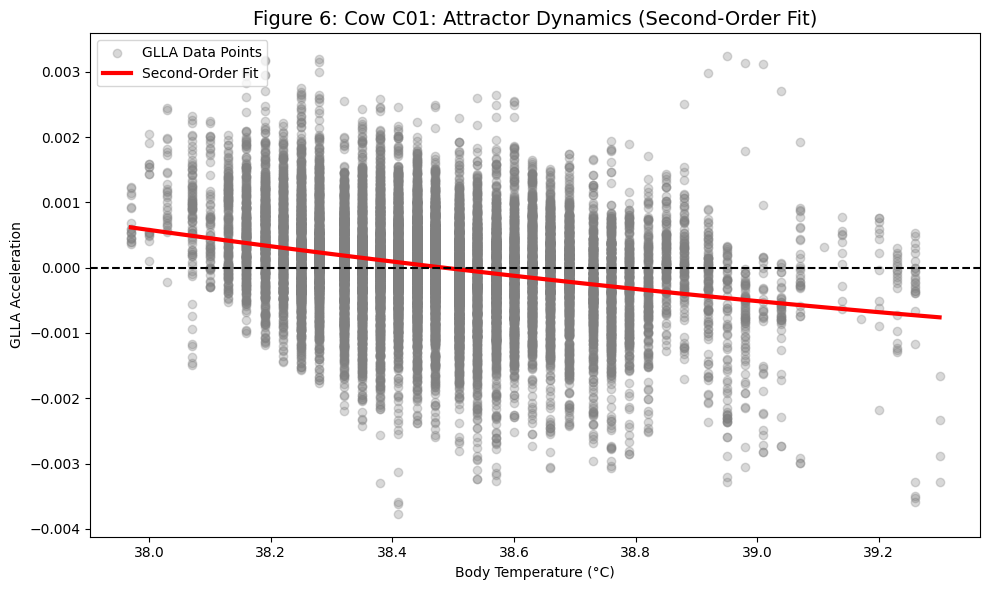

In [17]:
c, b1, b2 = 1.25e-05, -0.0011, 0.0002
roots = np.roots([b2, b1, c])
real_roots = roots[np.isreal(roots)].real
avg_temp = model_data['temperature_C'].mean()
set_points = real_roots + avg_temp
print(f"Calculated Set Points: {set_points}")
plt.figure(figsize=(10, 6))
plt.scatter(model_data['temperature_C'], model_data['accel_GLLA2'], 
            alpha=0.3, color='gray', label='GLLA Data Points')

x_range = np.linspace(model_data['temperature_C'].min(), model_data['temperature_C'].max(), 100)
x_centered = x_range - avg_temp
y_pred = c + (b1 * x_centered) + (b2 * x_centered**2)
plt.plot(x_range, y_pred, color='red', linewidth=3, label='Second-Order Fit')
plt.axhline(0, color='black', linestyle='--')
plt.title('Figure 6: Cow C01: Attractor Dynamics (Second-Order Fit)', fontsize=14)
plt.xlabel('Body Temperature (°C)')
plt.ylabel('GLLA Acceleration')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


The results of the second-order OLS regression (Figure 5) demonstrate that both the linear term and the higher-order acceleration term are statistically significant (p < 0.01), suggesting the presence of an underlying attractor. To account for the low Durbin-Watson score, which indicates a high degree of autocorrelation , HAC robust standard errors were employed to ensure the validity of the results. Using the coefficients derived from this model, we will construct a function to confirm the attractor's stability and calculate the systems set points.Figure 6 shows that we have successfully calculated a fixed point attractor , since the fited line crosses the nullcline. This attractor is calculated to be roughly at 38.48 degree . We know that it is an attractor since the slope is negative. However, the slope is not very steep meaning that the strenght of the attractor is not that strong.